In [243]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.impute import SimpleImputer

sys.path.insert(0, '..')
from imports.Lab_2_4_LR2 import one_hot_encode

### Carga del dataset

In [244]:
df = pd.read_csv("../data/rendimiento_estudiantes_train.csv")

### Información del dataset

In [245]:
categorias_validas = ['docencia', 'otros', 'sanidad', 'servicios']

# Inicializa columnas finales con False (0)
for categoria in categorias_validas:
    df[categoria] = 0

# Marca como 1 las categorías correspondientes en Mtrab y Ptrab
for categoria in categorias_validas:
    df[categoria] = ((df['Mtrab'] == categoria) | (df['Ptrab'] == categoria)).astype(int)

df[categorias_validas]
df.drop(columns=["Mtrab","Ptrab"])
df.columns

Index(['escuela', 'sexo', 'edad', 'entorno', 'TamFam', 'EstPadres', 'Medu',
       'Pedu', 'Mtrab', 'Ptrab', 'razon', 'tutor', 'TiempoViaje',
       'TiempoEstudio', 'suspensos', 'apoyo', 'ApFam', 'academia', 'extras',
       'enfermeria', 'EstSup', 'internet', 'pareja', 'RelFam', 'TiempoLib',
       'SalAm', 'AlcSem', 'AlcFin', 'salud', 'faltas', 'asignatura', 'T1',
       'T2', 'T3', 'docencia', 'otros', 'sanidad', 'servicios'],
      dtype='object')

In [246]:
df.shape

(835, 38)

In [247]:
df.head()

,escuela,sexo,edad,entorno,TamFam,EstPadres,Medu,Pedu,Mtrab,Ptrab,...,salud,faltas,asignatura,T1,T2,T3,docencia,otros,sanidad,servicios
0,IC,M,19,U,>=4,J,2.0,1.0,casa,otros,...,5,210.910377,L,8,9,9,0,1,0,0
1,BG,F,18,U,>=4,J,4.0,4.0,sanidad,sanidad,...,4,15.000000,M,9,8,8,0,0,1,0
2,BG,F,16,R,>=4,J,4.0,4.0,sanidad,docencia,...,4,0.000000,L,17,16,16,1,0,1,0
3,BG,F,16,U,<4,J,4.0,3.0,docencia,servicios,...,1,2.000000,L,16,15,16,1,0,0,1
4,BG,M,18,U,<4,J,3.0,3.0,servicios,sanidad,...,4,13.000000,M,6,6,8,0,0,1,1


In [248]:
df.columns

Index(['escuela', 'sexo', 'edad', 'entorno', 'TamFam', 'EstPadres', 'Medu',
       'Pedu', 'Mtrab', 'Ptrab', 'razon', 'tutor', 'TiempoViaje',
       'TiempoEstudio', 'suspensos', 'apoyo', 'ApFam', 'academia', 'extras',
       'enfermeria', 'EstSup', 'internet', 'pareja', 'RelFam', 'TiempoLib',
       'SalAm', 'AlcSem', 'AlcFin', 'salud', 'faltas', 'asignatura', 'T1',
       'T2', 'T3', 'docencia', 'otros', 'sanidad', 'servicios'],
      dtype='object')

In [249]:
df.describe()

,edad,Medu,Pedu,TiempoViaje,TiempoEstudio,suspensos,RelFam,TiempoLib,SalAm,AlcSem,AlcFin,salud,faltas,T1,T2,T3,docencia,otros,sanidad,servicios
count,835.000000,783.000000,731.000000,835.000000,819.000000,835.000000,818.000000,835.000000,835.000000,815.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,16.755689,2.628352,2.410397,1.520958,1.957265,0.283832,3.904645,3.201198,3.132934,1.505521,2.276647,3.553293,9.682235,11.204790,11.238323,11.326946,0.166467,0.664671,0.106587,0.410778
std,1.244730,1.115372,1.114586,0.711656,0.829988,0.680079,0.950786,1.030819,1.147536,0.920504,1.274682,1.425352,33.985657,3.066016,3.381352,3.993061,0.372723,0.472388,0.308772,0.492270
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000,0.000000,0.000000,0.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000,0.000000,1.000000,0.000000,0.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,7.000000,13.000000,13.000000,14.000000,0.000000,1.000000,0.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,246.036983,19.000000,19.000000,20.000000,1.000000,1.000000,1.000000,1.000000


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   escuela        835 non-null    object 
 1   sexo           835 non-null    object 
 2   edad           835 non-null    int64  
 3   entorno        835 non-null    object 
 4   TamFam         835 non-null    object 
 5   EstPadres      835 non-null    object 
 6   Medu           783 non-null    float64
 7   Pedu           731 non-null    float64
 8   Mtrab          835 non-null    object 
 9   Ptrab          835 non-null    object 
 10  razon          835 non-null    object 
 11  tutor          835 non-null    object 
 12  TiempoViaje    835 non-null    int64  
 13  TiempoEstudio  819 non-null    float64
 14  suspensos      835 non-null    int64  
 15  apoyo          835 non-null    object 
 16  ApFam          835 non-null    object 
 17  academia       835 non-null    object 
 18  extras    

"Missing values" por categoría

In [251]:
df.isnull().sum()

escuela            0
sexo               0
edad               0
entorno            0
TamFam             0
EstPadres          0
Medu              52
Pedu             104
Mtrab              0
Ptrab              0
razon              0
tutor              0
TiempoViaje        0
TiempoEstudio     16
suspensos          0
apoyo              0
ApFam              0
academia           0
extras             0
enfermeria         0
EstSup             0
internet           0
pareja             0
RelFam            17
TiempoLib          0
SalAm              0
AlcSem            20
AlcFin             0
salud              0
faltas             0
asignatura         0
T1                 0
T2                 0
T3                 0
docencia           0
otros              0
sanidad            0
servicios          0
dtype: int64

> Podemos observar que sobre todo hay datos faltantes para la educacion del padre. Además hay algunos datos faltantes en las variables TiempoEstudio RelFam y AlcSem.

### Separación de las variables

In [252]:
categorical_vars = [
    'escuela', 'sexo', 'entorno', 'TamFam', 'EstPadres', 'Mtrab', 'Ptrab',
    'razon', 'tutor', 'apoyo', 'ApFam', 'academia', 'extras', 'enfermeria',
    'EstSup', 'internet', 'pareja', 'asignatura'
]

discrete_vars = [
    'edad', 'Medu', 'Pedu', 'TiempoViaje', 'TiempoEstudio', 'suspensos',
    'RelFam', 'TiempoLib', 'SalAm', 'AlcSem', 'AlcFin', 'salud'
]
# Tomamos la variable faltas como continua por la cantidad de valores que puede tomar
continuous_vars = ['faltas', 'T1', 'T2', 'T3']

### Análisis en variables categóricas

In [253]:
for col in categorical_vars:
    if col in df.columns:
        print(f"\n=== Frecuencias de la columna '{col}' ===")
        print(df[col].value_counts(dropna=False))


=== Frecuencias de la columna 'escuela' ===
escuela
BG    617
IC    218
Name: count, dtype: int64

=== Frecuencias de la columna 'sexo' ===
sexo
F    473
M    362
Name: count, dtype: int64

=== Frecuencias de la columna 'entorno' ===
entorno
U    603
R    232
Name: count, dtype: int64

=== Frecuencias de la columna 'TamFam' ===
TamFam
>=4    586
<4     249
Name: count, dtype: int64

=== Frecuencias de la columna 'EstPadres' ===
EstPadres
J    738
S     97
Name: count, dtype: int64

=== Frecuencias de la columna 'Mtrab' ===
Mtrab
otros        311
servicios    194
casa         154
docencia     108
sanidad       68
Name: count, dtype: int64

=== Frecuencias de la columna 'Ptrab' ===
Ptrab
otros        467
servicios    231
docencia      56
casa          48
sanidad       33
Name: count, dtype: int64

=== Frecuencias de la columna 'razon' ===
razon
optativas     348
cercania      204
reputacion    198
otras          56
otros          29
Name: count, dtype: int64

=== Frecuencias de la colum

> Podemos observar que en la columna razon hay un error en los datos ya que hay valores "otras" y "otros". Arreglamos esto

In [254]:
df['razon'] = df['razon'].replace('otras', 'otros')

### Correlación entre variables

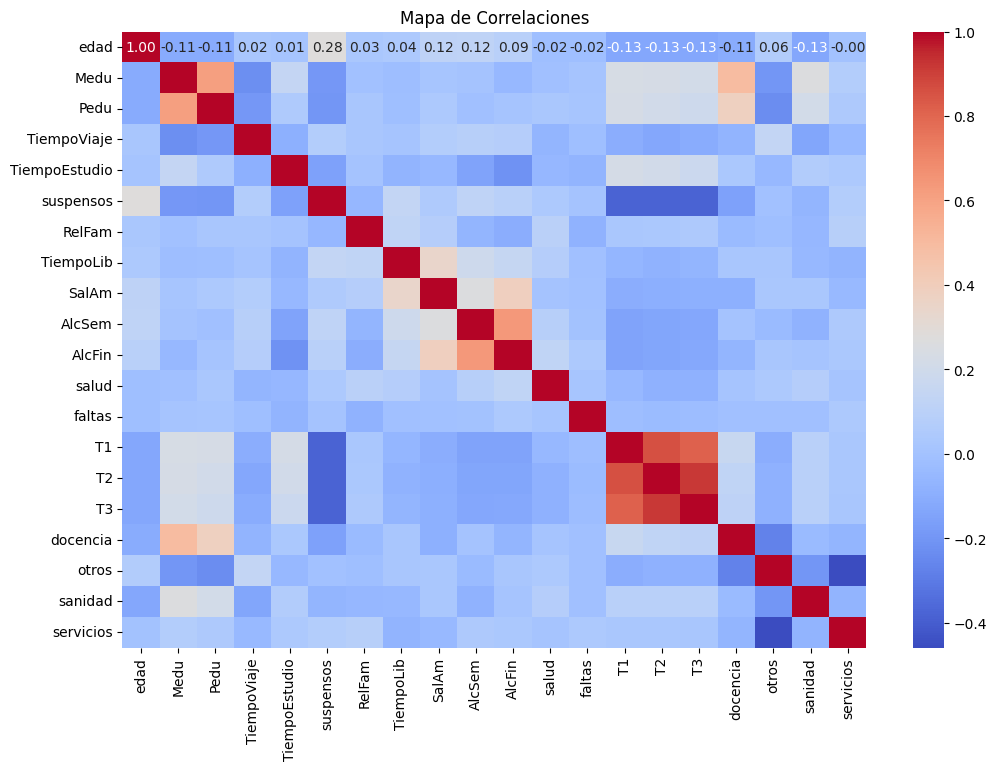

In [255]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
matriz_correlacion = df[numerical_cols].corr()
# Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de Correlaciones")
plt.show()

>Observamos que claramente T1, T2 y T3 están altamente correlacionadas. Además podemos ver una correlación entre las variables AlcSem y AlcFin pero no es suficientemente notable como para poder interpretarlo y que nos aporte información.

### Distribución de variables

In [256]:

# print("=== Histogramas para VARIABLES CATEGÓRICAS ===")
# for col in categorical_vars:
#     if col in df.columns:
#         plt.figure(figsize=(6, 4))
#         sns.countplot(data=df, x=col, color='skyblue')
#         plt.title(f"{col} (countplot)")
#         plt.xlabel(col)
#         plt.ylabel("Count")
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()


# print("=== Histogramas para VARIABLES DISCRETAS ===")
# for col in discrete_vars:
#     if col in df.columns:
#         plt.figure(figsize=(6, 4))
#         sns.countplot(data=df, x=col, color='lightgreen')
#         plt.title(f"{col} (countplot)")
#         plt.xlabel(col)
#         plt.ylabel("Count")
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()


# print("=== Histogramas para VARIABLES CONTINUAS ===")
# for col in continuous_vars:
#     if col in df.columns:
#         plt.figure(figsize=(6, 4))
#         sns.histplot(data=df, x=col, kde=True, color='salmon')
#         plt.title(f"{col} (histplot)")
#         plt.xlabel(col)
#         plt.ylabel("Frecuencia")
#         plt.tight_layout()
#         plt.show()


### Boxplots para detectar outliers

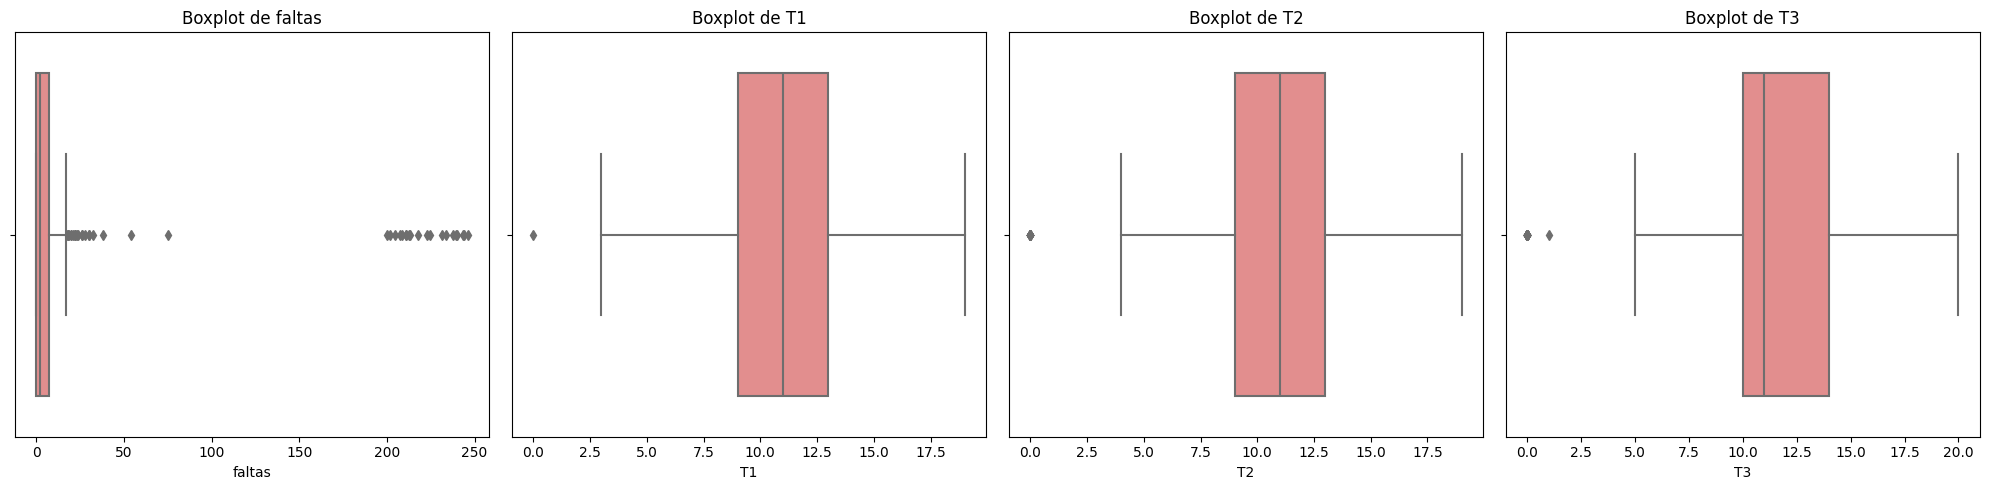

In [257]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # Crear una figura con 4 subplots en una fila

for i, col in enumerate(continuous_vars):
    if col in df.columns:
        sns.boxplot(data=df, x=col, color='lightcoral', ax=axes[i])  # Asignar cada gráfico a un subplot
        axes[i].set_title(f"Boxplot de {col}")

plt.tight_layout()  # Ajustar el diseño para evitar superposición
plt.show()

Primero vamos a ver qué hacemos con todos los outliers que aparecen en la clase faltas

In [258]:
faltas_mayores_100 = df['faltas'][df['faltas'] > 100]
faltas_sin_decimales = faltas_mayores_100[faltas_mayores_100 % 1 != 0]
print(faltas_sin_decimales)
print(len(faltas_mayores_100) == len(faltas_sin_decimales))

0      210.910377
32     243.703589
79     233.638231
98     246.036983
104    202.002956
178    204.688826
215    212.483448
227    237.513288
259    213.162367
296    243.533452
328    211.025213
343    222.916180
350    239.629741
372    239.796319
530    224.306524
554    207.602428
586    200.032670
654    208.756157
694    231.366447
790    217.560969
Name: faltas, dtype: float64
True


>Los outilers mayores que 100 son claramente errores en los datos ya que no puede haber faltas decimales. El resto de outliers en las variables son valores que aportan información.

In [259]:
df.loc[df['faltas'] > 100, 'faltas'] = np.nan

Ahora vemos que hacer con los missing values


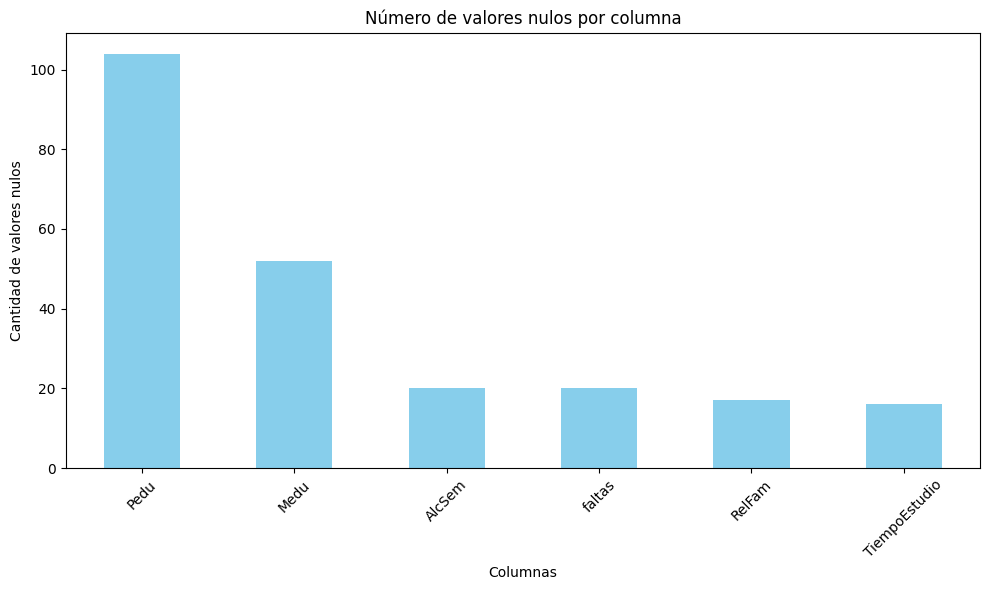

In [260]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 6))
missing_values.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Número de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de valores nulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


> Como hay muchos datos con missing values no podemos eliminarlos ya que estaríamos quitando mucha información.

In [261]:
missing_cols = [col for col in df.columns if df[col].isnull().any()]
imputer = SimpleImputer(strategy='median')
df[missing_cols] = imputer.fit_transform(df[missing_cols])


In [262]:
df_con_missing = df[df.isnull().any(axis=1)]
print(df_con_missing.head())

Empty DataFrame
Columns: [escuela, sexo, edad, entorno, TamFam, EstPadres, Medu, Pedu, Mtrab, Ptrab, razon, tutor, TiempoViaje, TiempoEstudio, suspensos, apoyo, ApFam, academia, extras, enfermeria, EstSup, internet, pareja, RelFam, TiempoLib, SalAm, AlcSem, AlcFin, salud, faltas, asignatura, T1, T2, T3, docencia, otros, sanidad, servicios]
Index: []

[0 rows x 38 columns]


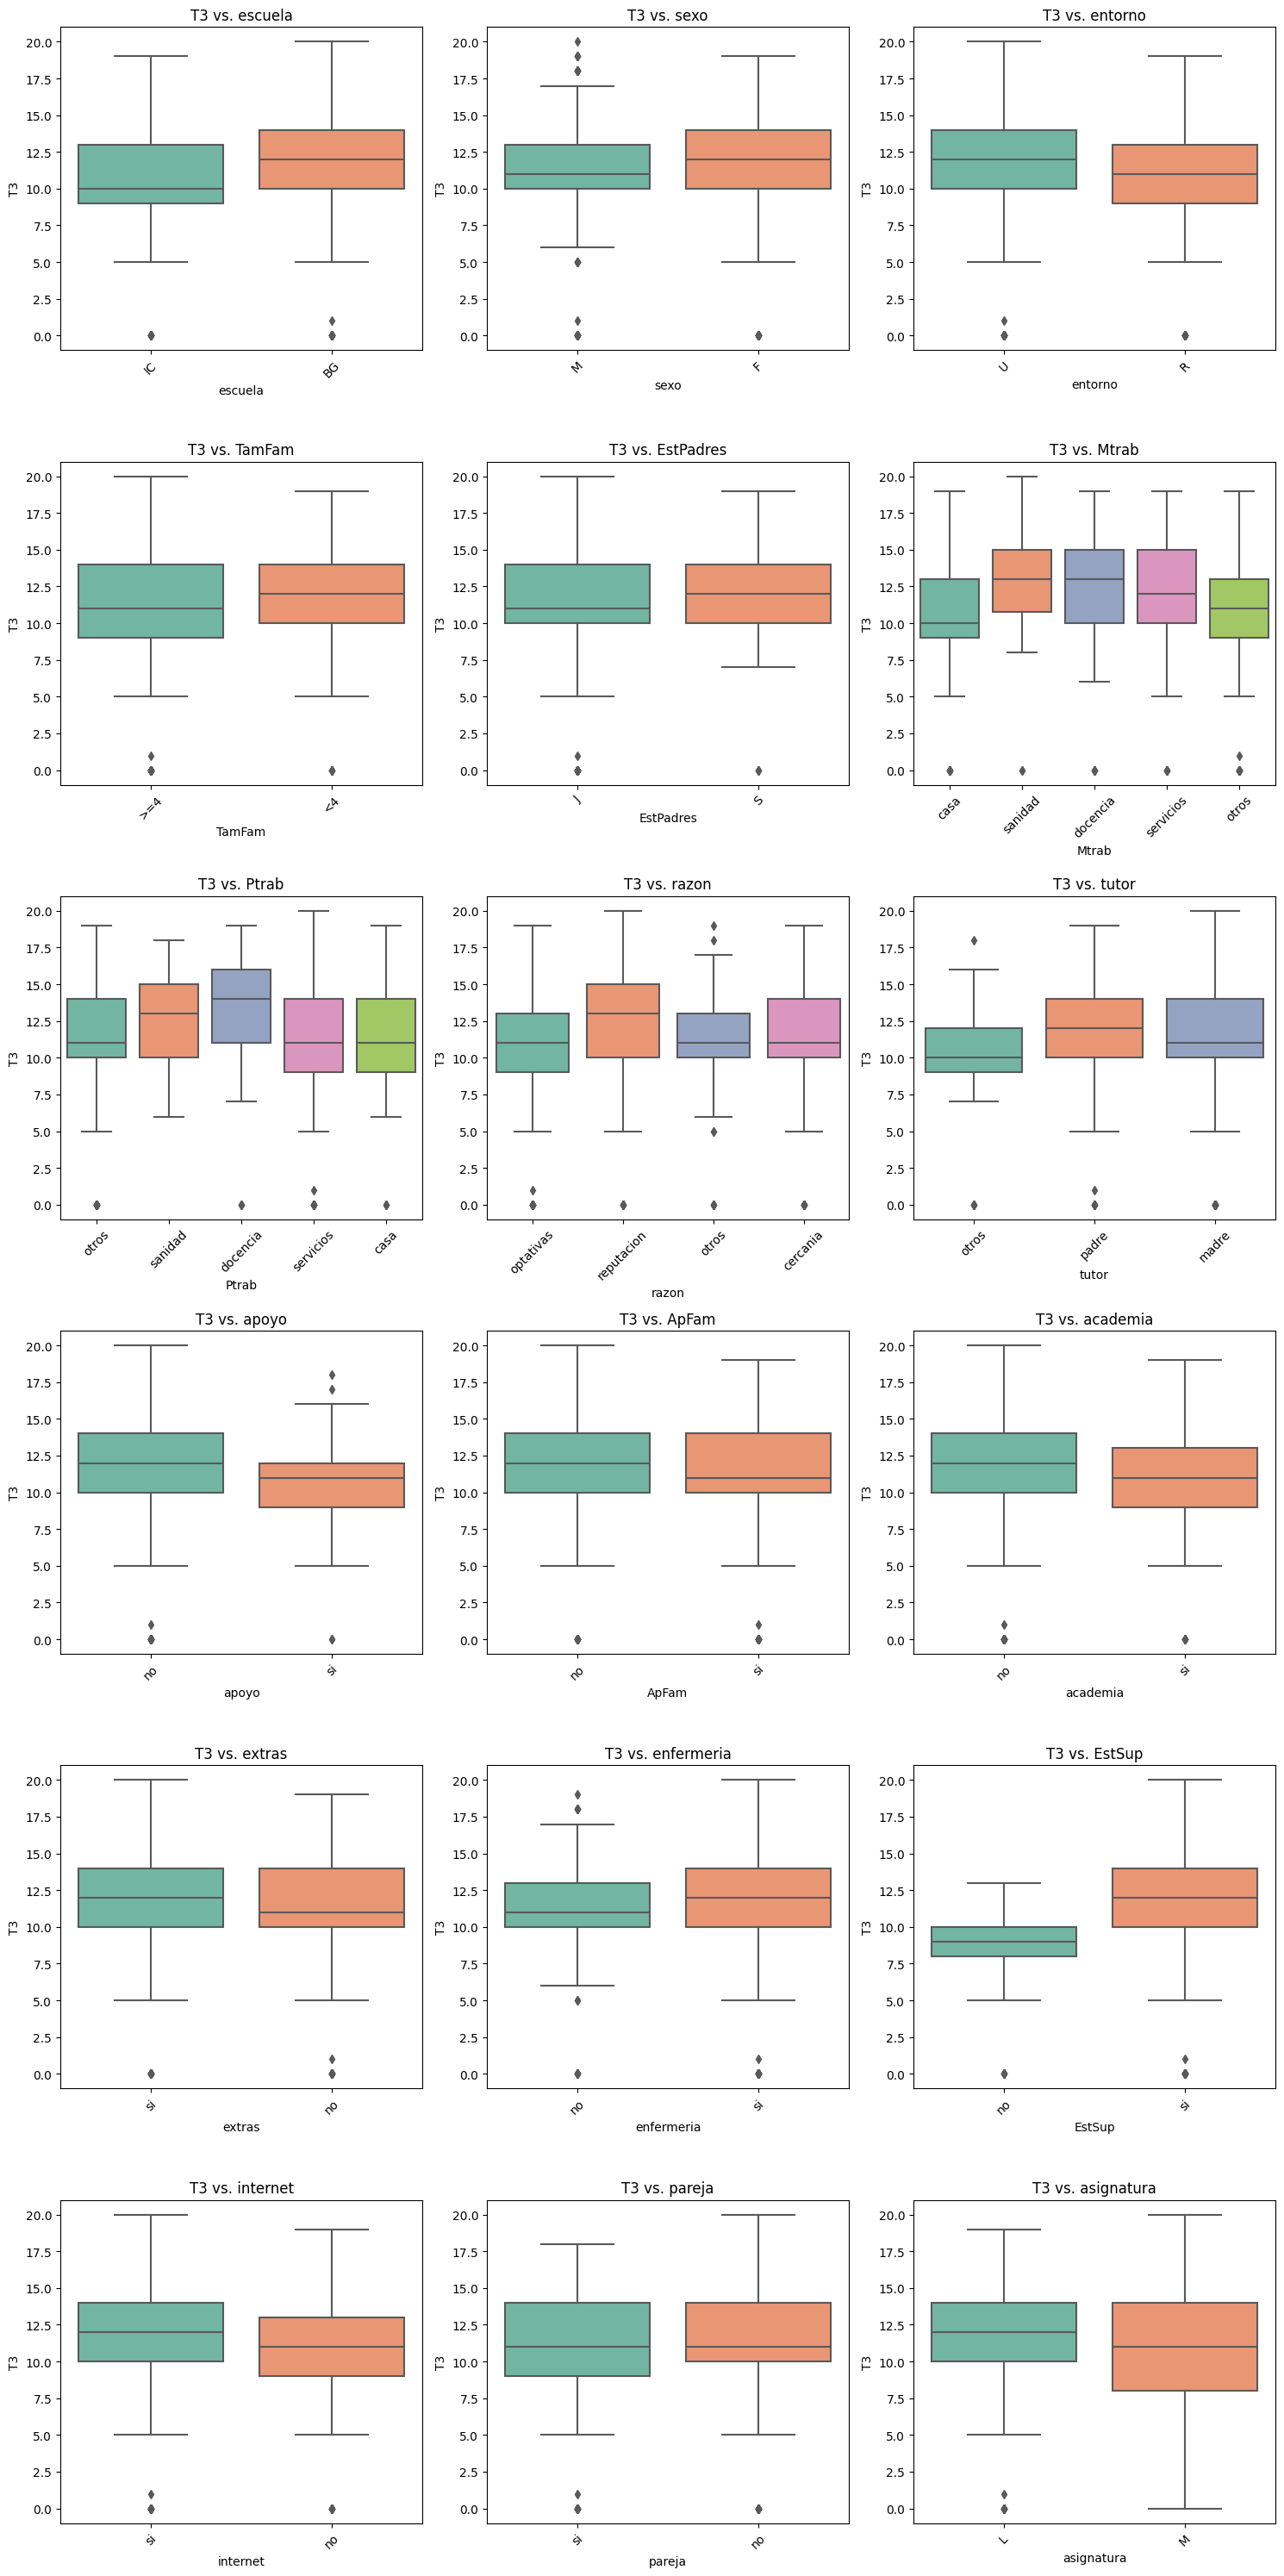

In [263]:
import math

# Número de gráficos por fila
graficos_por_fila = 3
num_categorias = len(categorical_vars)
num_filas = math.ceil(num_categorias / graficos_por_fila)

fig, axes = plt.subplots(num_filas, graficos_por_fila, figsize=(15, 5 * num_filas))
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

for i, cat in enumerate(categorical_vars):
    if cat in df.columns:
        sns.boxplot(data=df, x=cat, y='T3', palette='Set2', ax=axes[i])
        axes[i].set_title(f"T3 vs. {cat}")
        axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos si hay menos categorías que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


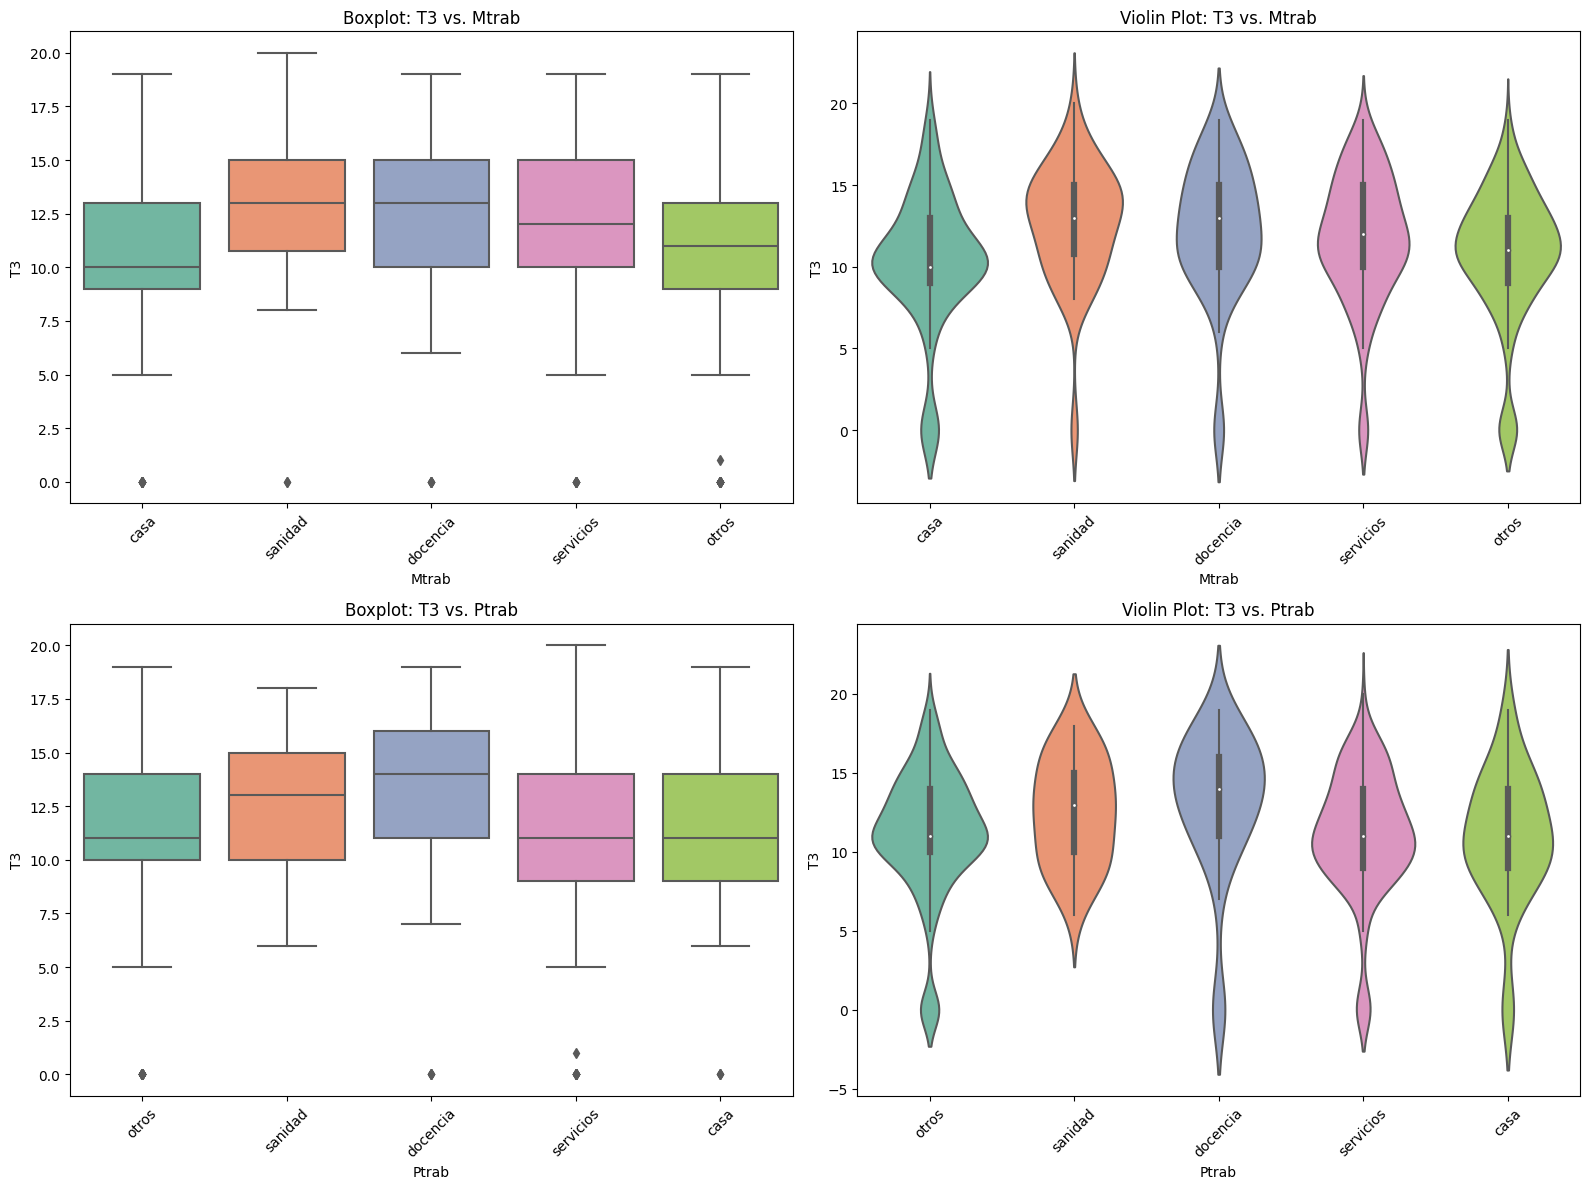

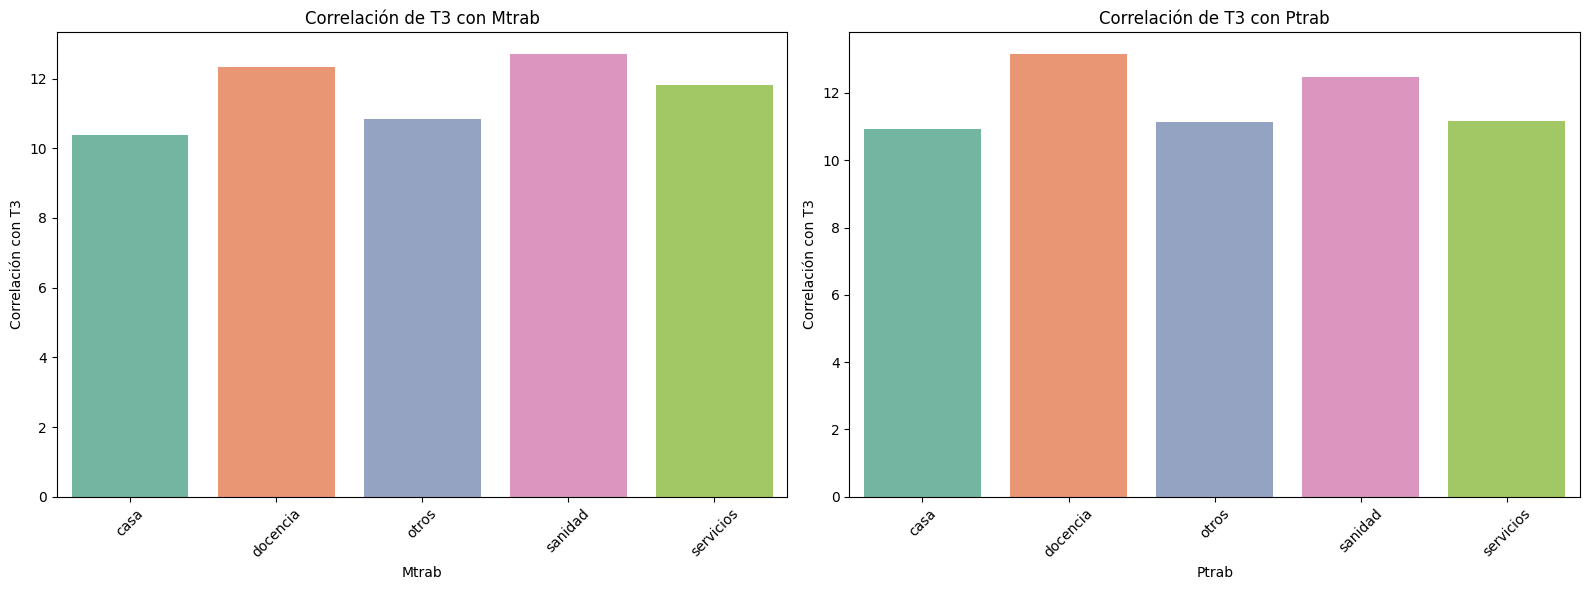

In [264]:
# Graficar boxplots y violin plots para Mtrab y Ptrab
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot para Mtrab
sns.boxplot(data=df, x='Mtrab', y='T3', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot: T3 vs. Mtrab')
axes[0, 0].tick_params(axis='x', rotation=45)

# Violin plot para Mtrab
sns.violinplot(data=df, x='Mtrab', y='T3', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Violin Plot: T3 vs. Mtrab')
axes[0, 1].tick_params(axis='x', rotation=45)

# Boxplot para Ptrab
sns.boxplot(data=df, x='Ptrab', y='T3', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot: T3 vs. Ptrab')
axes[1, 0].tick_params(axis='x', rotation=45)

# Violin plot para Ptrab
sns.violinplot(data=df, x='Ptrab', y='T3', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Violin Plot: T3 vs. Ptrab')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
# Calcular la media de T3 para cada grupo de Mtrab y Ptrab
correlaciones_mtrab = df.groupby('Mtrab')['T3'].mean()
correlaciones_ptrab = df.groupby('Ptrab')['T3'].mean()

# Graficar las correlaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlación con Mtrab
sns.barplot(x=correlaciones_mtrab.index, y=correlaciones_mtrab.values, ax=axes[0], palette='Set2')
axes[0].set_title('Correlación de T3 con Mtrab')
axes[0].set_xlabel('Mtrab')
axes[0].set_ylabel('Correlación con T3')
axes[0].tick_params(axis='x', rotation=45)

# Correlación con Ptrab
sns.barplot(x=correlaciones_ptrab.index, y=correlaciones_ptrab.values, ax=axes[1], palette='Set2')
axes[1].set_title('Correlación de T3 con Ptrab')
axes[1].set_xlabel('Ptrab')
axes[1].set_ylabel('Correlación con T3')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
categorias_validas = ['docencia', 'otros', 'sanidad', 'servicios']
discrete_vars += categorias_validas
for categoria in categorias_validas:
    df[categoria] = ((df['Mtrab'] == categoria) | (df['Ptrab'] == categoria)).astype(int)

df.drop(columns=["Mtrab","Ptrab"], inplace=True)

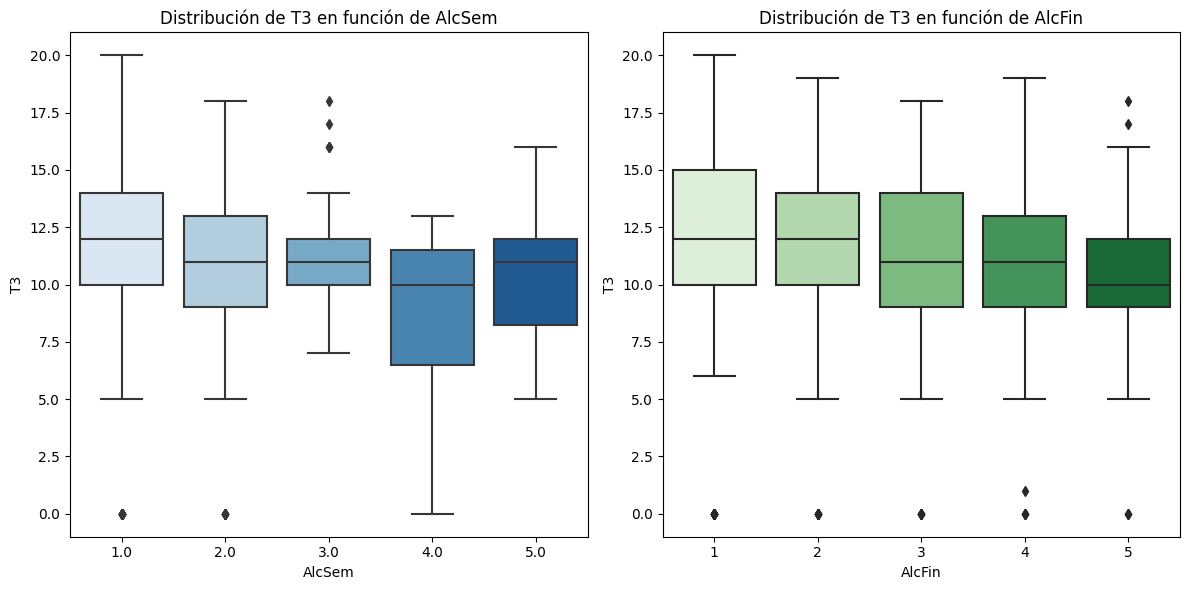

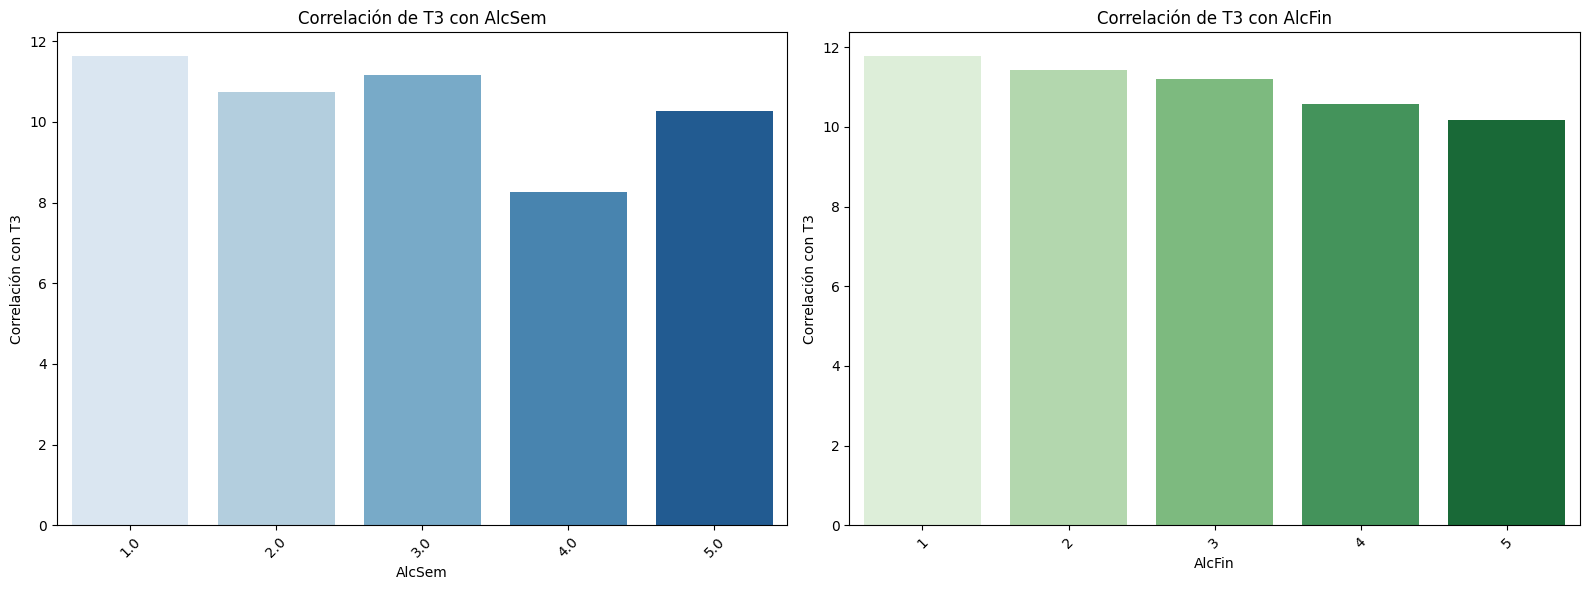

In [265]:
# Distribución de T3 en función de AlcSem
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='AlcSem', y='T3', palette='Blues')
plt.title('Distribución de T3 en función de AlcSem')
plt.xlabel('AlcSem')
plt.ylabel('T3')

# Distribución de T3 en función de AlcFin
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='AlcFin', y='T3', palette='Greens')
plt.title('Distribución de T3 en función de AlcFin')
plt.xlabel('AlcFin')
plt.ylabel('T3')

plt.tight_layout()
plt.show()

# Calcular la media de T3 para cada grupo de AlcSem y AlcFin
correlaciones_alcsem = df.groupby('AlcSem')['T3'].mean()
correlaciones_alcfin = df.groupby('AlcFin')['T3'].mean()

# Graficar las correlaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlación con AlcSem
sns.barplot(x=correlaciones_alcsem.index, y=correlaciones_alcsem.values, ax=axes[0], palette='Blues')
axes[0].set_title('Correlación de T3 con AlcSem')
axes[0].set_xlabel('AlcSem')
axes[0].set_ylabel('Correlación con T3')
axes[0].tick_params(axis='x', rotation=45)

# Correlación con AlcFin
sns.barplot(x=correlaciones_alcfin.index, y=correlaciones_alcfin.values, ax=axes[1], palette='Greens')
axes[1].set_title('Correlación de T3 con AlcFin')
axes[1].set_xlabel('AlcFin')
axes[1].set_ylabel('Correlación con T3')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Podemos observar como para valores altos de AlcSem y AlcFin, la nota de T3 tiende a reducirse, por lo que tendría sentido agrupar ambas variables teniendo en cuenta que hay 7 días en una semana.

In [266]:
df['Alc_comb'] = (5/7) * df['AlcSem'] + (2/7) * df['AlcFin']
df.drop(columns=["AlcSem","AlcFin"], inplace=True)

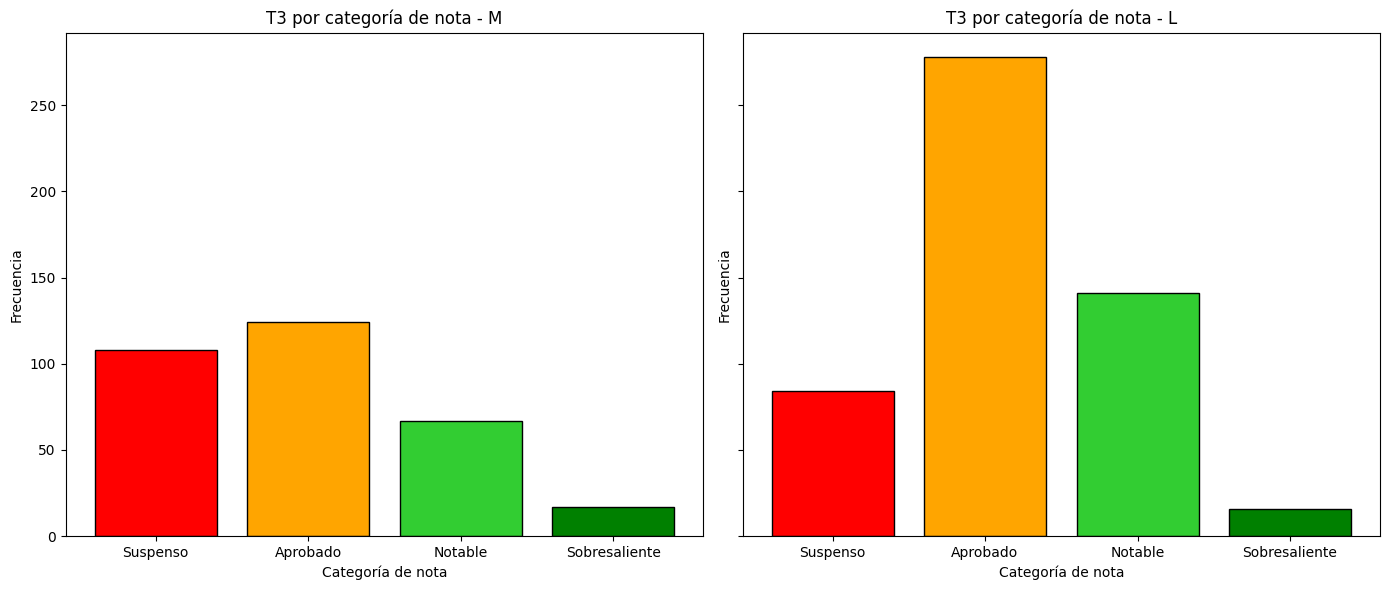

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Definir rangos de notas y colores
rango_notas = {
    'Suspenso': {'min': 0, 'max': 10, 'color': 'red'},
    'Aprobado': {'min': 10, 'max': 14, 'color': 'orange'},
    'Notable': {'min': 14, 'max': 18, 'color': 'limegreen'},
    'Sobresaliente': {'min': 18, 'max': 20.01, 'color': 'green'}  # 20.01 para incluir el 20
}

asignaturas_interes = ['M', 'L']
df_filtrado = df[df['asignatura'].isin(asignaturas_interes)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, asignatura in enumerate(asignaturas_interes):
    df_asig = df_filtrado[df_filtrado['asignatura'] == asignatura]
    
    # Contar ocurrencias por rango
    conteos = {}
    for nombre, rango in rango_notas.items():
        conteos[nombre] = df_asig[(df_asig['T3'] >= rango['min']) & (df_asig['T3'] < rango['max'])].shape[0]
    
    # Graficar barras manualmente
    nombres_rangos = list(conteos.keys())
    alturas = list(conteos.values())
    colores = [rango_notas[r]['color'] for r in nombres_rangos]

    axes[i].bar(nombres_rangos, alturas, color=colores, edgecolor='black')
    axes[i].set_title(f'T3 por categoría de nota - {asignatura}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('Categoría de nota')

plt.tight_layout()
plt.show()


In [292]:
df[(df['faltas'] > 20)]

,escuela,sexo,edad,entorno,TamFam,EstPadres,Medu,Pedu,Mtrab,Ptrab,...,faltas,asignatura,T1,T2,T3,docencia,otros,sanidad,servicios,Alc_comb
20,BG,M,17,U,<4,S,4.0,2.0,servicios,otros,...,30.0,M,8,8,8,0,1,0,1,2.571429
108,BG,M,17,U,<4,S,4.0,1.0,servicios,otros,...,22.0,L,11,11,10,0,1,0,1,2.571429
109,BG,F,17,U,>=4,J,3.0,4.0,casa,servicios,...,28.0,M,10,9,9,0,0,0,1,3.285714
114,BG,M,18,U,>=4,J,4.0,4.0,docencia,servicios,...,22.0,M,9,9,9,1,0,0,1,1.857143
166,BG,F,17,U,>=4,S,4.0,3.0,servicios,servicios,...,23.0,M,13,13,13,0,0,0,1,1.285714
208,BG,M,19,U,>=4,J,4.0,4.0,docencia,servicios,...,38.0,M,8,9,8,1,0,0,1,1.000000
274,BG,M,18,U,>=4,J,2.0,2.0,otros,casa,...,26.0,L,7,8,8,0,1,0,0,2.000000
282,BG,F,18,U,>=4,J,4.0,3.0,servicios,otros,...,21.0,M,17,18,18,0,1,0,1,1.571429
370,BG,F,18,R,>=4,S,3.0,2.0,otros,servicios,...,75.0,M,10,9,9,0,1,0,1,1.000000
507,BG,F,15,U,>=4,J,3.0,2.0,servicios,otros,...,26.0,M,7,6,6,0,1,0,1,1.000000


c:\Users\gonza\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


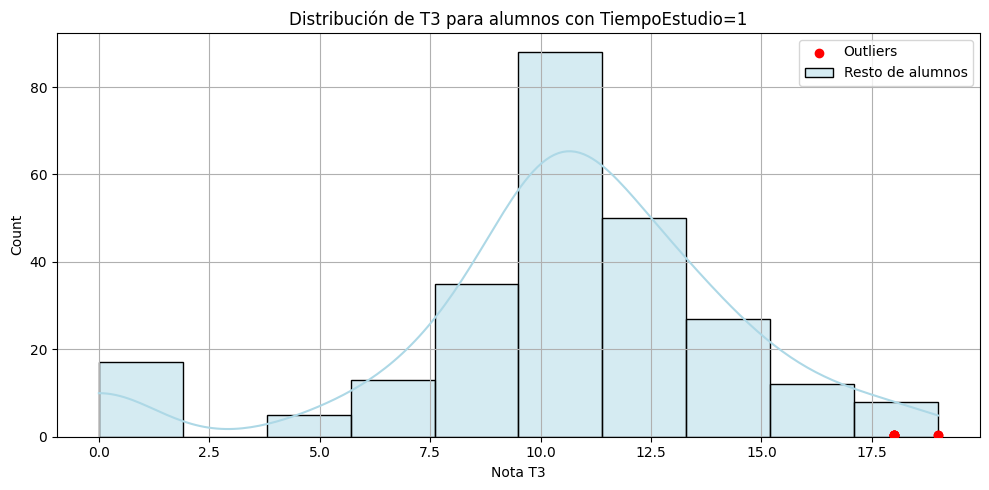

c:\Users\gonza\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


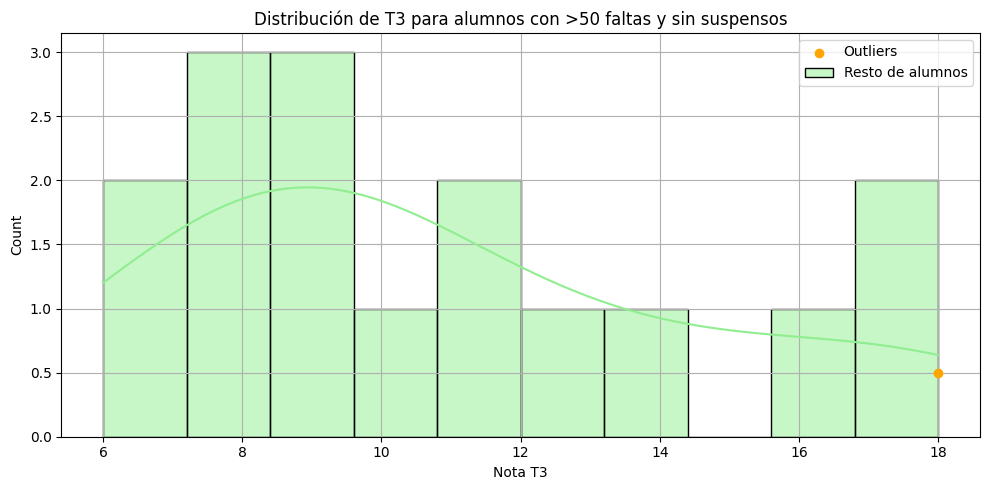

In [ ]:

# --- Outliers definidos ---
outliers_tiempo_estudio = df[(df['TiempoEstudio'] == 1) & (df['T3'] > 17)]
outliers_faltas = df[(df['faltas'] > 20) & (df['suspensos'] == 0) & (df['T3'] > 17)]

# Grupos de comparación
grupo_tiempo_estudio = df[(df['TiempoEstudio'] == 1)]
grupo_faltas = df[(df['faltas'] > 20)]

# Crear gráfico de comparación para TiempoEstudio
plt.figure(figsize=(10, 5))
sns.histplot(grupo_tiempo_estudio['T3'], color='lightblue', bins=10, label='Resto de alumnos', kde=True)
plt.scatter(outliers_tiempo_estudio['T3'], [0.5]*len(outliers_tiempo_estudio), color='red', label='Outliers', zorder=5)
plt.title('Distribución de T3 para alumnos con TiempoEstudio=1')
plt.xlabel('Nota T3')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Crear gráfico de comparación para Faltas
plt.figure(figsize=(10, 5))
sns.histplot(grupo_faltas['T3'], color='lightgreen', bins=10, label='Resto de alumnos', kde=True)
plt.scatter(outliers_faltas['T3'], [0.5]*len(outliers_faltas), color='orange', label='Outliers', zorder=5)
plt.title('Distribución de T3 para alumnos con >50 faltas y sin suspensos')
plt.xlabel('Nota T3')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Filtrar estudiantes con T2 = 0 y mostrar la nota de T3
t3_notas = df[df['T2'] == 0]['T3']
print(t3_notas)


95     0
111    0
129    0
134    0
140    0
164    0
180    0
247    0
318    0
373    0
455    0
519    0
562    0
605    0
700    0
744    0
751    0
Name: T3, dtype: int64
